# Calibrating and Cataloguing Green-band

In [2]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               

from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia # this library is used to query astronomical databases 


In [3]:
g_combined = CCDData.read("g_NGC_2547_med.fits", unit="adu")
print("Loaded g_combined successfully")

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
Loaded g_combined successfully


In [4]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('g_NGC_2547_med.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('g_NGC_2547_med.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

Solving............WCS added successfully!


In [5]:
scim=CCDData.read("g_NGC_2547_med.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 122.353111026 -48.8903566815 
CRPIX : 587.693748474 483.035991669 
CD1_1 CD1_2  : -0.000595667320789 0.000280896353715 
CD2_1 CD2_2  : -0.000281051929191 -0.000595612192856 
NAXIS : 1080  1920
Image stats (mean, median and standard deviation): -0.22979798913002014 -0.6589334011077881 10.493639945983887


In [7]:
outfile="segimage.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


In [33]:
# ── Load image and build source catalogue ─────────────────────────────────────
with fits.open('g_NGC_2547_med.fits') as hdul:
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

# ── Aperture photometry on all detected sources ───────────────────────────────
positions = []
for obj in source_table:
    positions.append((obj.centroid[0], obj.centroid[1]))

apertures  = CircularAperture(positions, r=20.0)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

# ── Gaia query ────────────────────────────────────────────────────────────────
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")
j = Gaia.cone_search_async(coordinate=coord, radius=radius)
r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

# ── Match each Gaia star to nearest source in phot_table ─────────────────────
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print("\n=== Candidate REFERENCE stars (G < 12) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists      = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest    = int(np.argmin(dists))
        flux       = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:   # added
            break

print("\n=== Candidate FAINT stars (15 < G < 18) ===")  # was 14 < G < 17
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:                     # was 14 < g < 17
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break


First 10 rows of photometry table:
 id      xcenter            ycenter          aperture_sum   
           pix                pix                           
--- ------------------ ------------------ ------------------
  1 239.40679808373358 2.9406144299334014  20252.39257254621
  2  632.0650576165172 1.2675086313018795 38159.284589127434
  3  764.9867258475023 2.2474478403133715  1094.317453478717
  4   792.719632563153 1.9966076749846675  76842.88304751829
  5   933.546817567662  3.448361881679689  6858.117510974699
  6  949.2643953676854 1.2014395264266602  5125.824259018912
  7 1031.2651453380827  9.483925514578033 11088.153980594367
  8  270.9142394771953 5.4609782658270145 -345.5837845794922
  9  701.2670482137827  6.413905909750036  8377.123916740084
 10 1070.0203275438066  3.475574107976759 -2956.883253245052

Column names: ['id', 'xcenter', 'ycenter', 'aperture_sum']

Querying Gaia DR3...
INFO: Query finished. [astroquery.utils.tap.core]
Gaia sources inside image footprint: 46

In [34]:
import numpy as np
#0       122.43434    -48.98048       571.9   640.4    0.6         
# ── Official Gaia DR3 → Johnson V transformation ──────────────────────────────
# Source: Gaia DR3 documentation (Riello et al. 2021)
# V = G + a0 + a1*(GBP-GRP) + a2*(GBP-GRP)^2 + a3*(GBP-GRP)^3
# Valid for GBP-GRP in range 0.0 to 2.5

a0 = -0.02704
a1 =  0.01424
a2 = -0.2156
a3 =  0.01426

def gaia_to_V(G, G_BP, G_RP):
    colour = G_BP - G_RP
    V = G + a0 + a1*colour + a2*colour**2 + a3*colour**3
    return V

# ── Reference star ────────────────────────────────────────────────────────────
G_BP_ref = 10.601
G_ref    = 10.386
G_RP_ref = 10.048
F_ref    = 128268.0

# ── Faint star ────────────────────────────────────────────────────────────────
  
G_BP_faint = 15.433
G_faint    = 15.000 
G_RP_faint = 14.406
F_faint    = 1949.8

V_ref        = gaia_to_V(G_ref,   G_BP_ref,   G_RP_ref)
V_faint_gaia = gaia_to_V(G_faint, G_BP_faint, G_RP_faint)

print("=== Reference Star ===")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated V magnitude: {V_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n=== Faint Star ===")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated V magnitude: {V_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# ── Sanity check ──────────────────────────────────────────────────────────────
V_faint_measured = V_ref - 2.5 * np.log10(F_faint / F_ref)

print("\n=== Sanity Check ===")
print(f"  V (from image photometry): {V_faint_measured:.3f}")
print(f"  V (from Gaia DR3 formula): {V_faint_gaia:.3f}")
print(f"  Difference:                {abs(V_faint_measured - V_faint_gaia):.3f} mag")
if abs(V_faint_measured - V_faint_gaia) < 0.5:
    print("  ✓ Good agreement — calibration is working correctly")
else:
    print("  ✗ Large discrepancy — check aperture photometry or star selection")

=== Reference Star ===
  GBP-GRP colour:         0.553
  Calibrated V magnitude: 10.303
  Measured flux (F_ref):  128268.0 ADU

=== Faint Star ===
  GBP-GRP colour:              1.027
  Gaia-calibrated V magnitude: 14.776
  Measured flux:               1949.8 ADU

=== Sanity Check ===
  V (from image photometry): 14.849
  V (from Gaia DR3 formula): 14.776
  Difference:                0.073 mag
  ✓ Good agreement — calibration is working correctly


=== Reference Star ===
  Johnson V:          10.303
  SeeStar Green:      10.268
  Net flux:           120358.7 ADU
  Background/pixel:   6.321 ADU

=== Calibration Summary ===
  Total sources:         3112
  Valid V magnitudes:    2827
  Magnitude range:       6.25 to 22.53

  idx        x        y     raw_flux    Green    V_mag
-------------------------------------------------------
    0   239.41     2.94      20252.4   12.203   12.252
    1   632.07     1.27      38159.3   11.515   11.564
    2   764.99     2.25       1094.3   15.371   15.421
    3   792.72     2.00      76842.9   10.755   10.804
    4   933.55     3.45       6858.1   13.379   13.428
    5   949.26     1.20       5125.8   13.695   13.744
    6  1031.27     9.48      11088.2   12.857   12.906
    7   270.91     5.46       -345.6      nan      nan
    8   701.27     6.41       8377.1   13.162   13.211
    9  1070.02     3.48      -2956.9      nan      nan
   10    77.90     9.39      11414.7   12.826   12.875
   11  

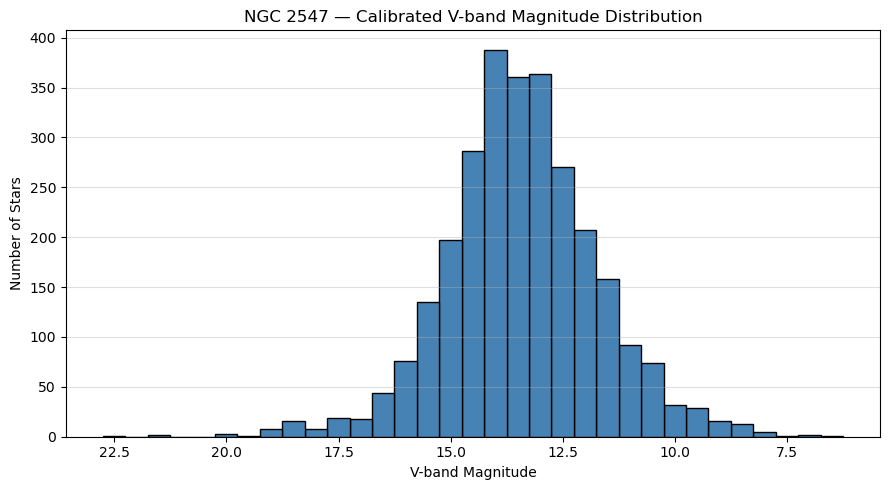

In [38]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

# ── Helper functions ──────────────────────────────────────────────────────────
def net_flux(data, pos, r_ap=20, r_in=25, r_out=40):
    """Background-subtracted aperture flux."""
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_V(G, G_BP, G_RP):
    """Gaia DR3 → Johnson V using official colour transformation."""
    a0, a1, a2, a3 = -0.02704, 0.01424, -0.2156, 0.01426
    return G + a0 + a1*(G_BP-G_RP) + a2*(G_BP-G_RP)**2 + a3*(G_BP-G_RP)**3

def BV_from_gaia(G_BP, G_RP):
    """Approximate Johnson B-V from Gaia colours."""
    return 1.35 * (G_BP - G_RP) - 0.10

def V_to_seestar_green(V, G_BP, G_RP):
    """Convert Johnson V to expected SeeStar Green magnitude."""
    BV = BV_from_gaia(G_BP, G_RP)
    return V - 0.07 * BV + 0.01

def seestar_green_to_V(green, G_BP, G_RP):
    """Convert measured SeeStar Green magnitude back to Johnson V."""
    BV = BV_from_gaia(G_BP, G_RP)
    return green + 0.07 * BV - 0.01

# ── Reference star: set from your chosen Gaia candidate ──────────────────────
# ✏️ Update these values to your chosen reference star from the Gaia table
G_BP_ref, G_ref, G_RP_ref = 10.601, 10.386, 10.048
x_ref, y_ref               = 380.3, 459.2

V_ref_johnson  = gaia_to_V(G_ref, G_BP_ref, G_RP_ref)
green_ref      = V_to_seestar_green(V_ref_johnson, G_BP_ref, G_RP_ref)
F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("=== Reference Star ===")
print(f"  Johnson V:          {V_ref_johnson:.3f}")
print(f"  SeeStar Green:      {green_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# ── Calibrate all sources ─────────────────────────────────────────────────────
maglist   = []   # Calibrated V magnitudes
greenlist = []   # SeeStar Green magnitudes (before V correction)

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        green_mag = green_ref - 2.5 * np.log10(flux_raw / F_ref)
        greenlist.append(green_mag)
        # For V conversion we don't have Gaia colours for every source,
        # so assume a typical cluster star colour (GBP-GRP ~ 0.7, BV ~ 0.85)
        # This is a reasonable approximation for NGC 2547 FGK members
        green_to_V_offset = 0.07 * (1.35 * 0.7 - 0.10) - 0.01   # = +0.047
        maglist.append(green_mag + green_to_V_offset)
    else:
        greenlist.append(np.nan)
        maglist.append(np.nan)

maglist   = np.array(maglist)
greenlist = np.array(greenlist)

# ── Summary statistics ────────────────────────────────────────────────────────
valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid V magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")

# ── Print first 20 results ────────────────────────────────────────────────────
print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Green':>8} {'V_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{greenlist[i]:>8.3f} {maglist[i]:>8.3f}")

# ── Histogram of calibrated V magnitudes ─────────────────────────────────────
import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='steelblue')
plt.xlabel('V-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated V-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("calibrated_V_band_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()



In [36]:
import pandas as pd
import numpy as np

# Create a dataframe from the results
df = pd.DataFrame({
    "x": phot_table['xcenter'].value,
    "y": phot_table['ycenter'].value,
    "raw_flux": phot_table['aperture_sum'],
    "green_mag": greenlist,
    "V_mag": maglist
})

# Optional: remove NaN magnitudes
df = df.replace([np.inf, -np.inf], np.nan)

# Save to CSV
df.to_csv("maglist_catalog.csv", index=False)

print("CSV saved as maglist_catalog.csv")

CSV saved as maglist_catalog.csv


# Calibrating and Cataloguing Blue band  

In [39]:
b_combined = CCDData.read("b_NGC_2547_med.fits", unit="adu")
print("Loaded b_combined successfully")

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
Loaded b_combined successfully


In [5]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('b_NGC_2547_med.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('b_NGC_2547_med.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

Solving....

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [ ]:
scim=CCDData.read("g_NGC_2547_med.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

In [17]:
outfile="segimage_b.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


In [7]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.wcs import WCS
from astropy.io import fits
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.segmentation import SourceCatalog, SegmentationImage
import astropy.stats
import numpy as np

# ── Load B-band image and build source catalogue ──────────────────────────────
with fits.open('b_NGC_2547_med.fits') as hdul:    # ✏️ B-band filename
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage_b.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

# ── Aperture photometry on all detected sources ───────────────────────────────
positions = []
valid_sources = []   # keep track of which sources had valid centroids

for obj in source_table:
    x, y = obj.centroid[0], obj.centroid[1]
    if np.isfinite(x) and np.isfinite(y):   # skip NaN centroids
        positions.append((x, y))
        valid_sources.append(obj)

print(f"Total sources in segmap:       {len(source_table)}")
print(f"Sources with valid centroids:  {len(positions)}")

apertures  = CircularAperture(positions, r=20.0)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

# ── Gaia query ────────────────────────────────────────────────────────────────
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")
j = Gaia.cone_search_async(coordinate=coord, radius=radius)
r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

# ── Match each Gaia star to nearest source in phot_table ─────────────────────
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print("\n=== Candidate REFERENCE stars (G < 12) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

print("\n=== Candidate FAINT stars (15 < G < 18) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

Total sources in segmap:       3112
Sources with valid centroids:  3111

First 10 rows of photometry table:
 id      xcenter            ycenter          aperture_sum   
           pix                pix                           
--- ------------------ ------------------ ------------------
  1  239.4428560946664   2.83259058998243 16316.204950754704
  2  632.0090308220152 1.1644603272773832 15558.271822731669
  3  764.9319693664185  2.125213187829765 1208.3084249695362
  4  792.8484116257231 1.5919162297780989  70127.84920064383
  5  932.9502706492214  3.125853281153668 4688.7269623673665
  6  948.0204173152517  2.022843727665861 3266.2396051602627
  7 1031.4580561309604  9.461207644724432   4864.37135178031
  8  270.6999222963067  6.023443542217765  245.5177869393412
  9  701.2362763025168  6.391739909145761 3838.0431926461133
 10 1069.6906084599511 3.1796928893230723  824.9237278589061

Column names: ['id', 'xcenter', 'ycenter', 'aperture_sum']

Querying Gaia DR3...
INFO: Query finis

In [3]:

a0 =  0.00786
a1 =  0.92062
a2 = -0.25444
a3 =  0.05068

def gaia_to_B(G, G_BP, G_RP):
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

# ── Reference star ────────────────────────────────────────────────────────────
G_BP_ref = 10.601
G_ref    = 10.386
G_RP_ref = 10.048
F_ref    = 93300.4       

# ── Faint star ────────────────────────────────────────────────────────────────
G_BP_faint = 15.433
G_faint    = 15.000
G_RP_faint = 14.406
F_faint    = 832.3     

B_ref        = gaia_to_B(G_ref,   G_BP_ref,   G_RP_ref)
B_faint_gaia = gaia_to_B(G_faint, G_BP_faint, G_RP_faint)

print("=== Reference Star ===")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated B magnitude: {B_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n=== Faint Star ===")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated B magnitude: {B_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# ── Sanity check ──────────────────────────────────────────────────────────────
B_faint_measured = B_ref - 2.5 * np.log10(F_faint / F_ref)

print("\n=== Sanity Check ===")
print(f"  B (from image photometry): {B_faint_measured:.3f}")
print(f"  B (from Gaia DR3 formula): {B_faint_gaia:.3f}")
print(f"  Difference:                {abs(B_faint_measured - B_faint_gaia):.3f} mag")
if abs(B_faint_measured - B_faint_gaia) < 0.5:
    print("  ✓ Good agreement — calibration is working correctly")
else:
    print("  ✗ Large discrepancy — check aperture photometry or star selection")

=== Reference Star ===
  GBP-GRP colour:         0.553
  Calibrated B magnitude: 10.834
  Measured flux (F_ref):  93300.4 ADU

=== Faint Star ===
  GBP-GRP colour:              1.027
  Gaia-calibrated B magnitude: 15.740
  Measured flux:               832.3 ADU

=== Sanity Check ===
  B (from image photometry): 15.958
  B (from Gaia DR3 formula): 15.740
  Difference:                0.218 mag
  ✓ Good agreement — calibration is working correctly


=== Reference Star ===
  Johnson B:          10.834
  SeeStar Blue:       10.436
  Net flux:           89433.8 ADU
  Background/pixel:   3.066 ADU

=== Calibration Summary ===
  Total sources:         3111
  Valid B magnitudes:    2670
  Magnitude range:       6.73 to 21.84

  idx        x        y     raw_flux     Blue    B_mag
-------------------------------------------------------
    0   239.44     2.83      16316.2   12.284   12.806
    1   632.01     1.16      15558.3   12.335   12.858
    2   764.93     2.13       1208.3   15.110   15.632
    3   792.85     1.59      70127.8   10.700   11.223
    4   932.95     3.13       4688.7   13.638   14.160
    5   948.02     2.02       3266.2   14.030   14.552
    6  1031.46     9.46       4864.4   13.598   14.120
    7   270.70     6.02        245.5   16.840   17.362
    8   701.24     6.39       3838.0   13.855   14.377
    9  1069.69     3.18        824.9   15.524   16.046
   10    77.79     9.49       8569.6   12.983   13.505
   11   

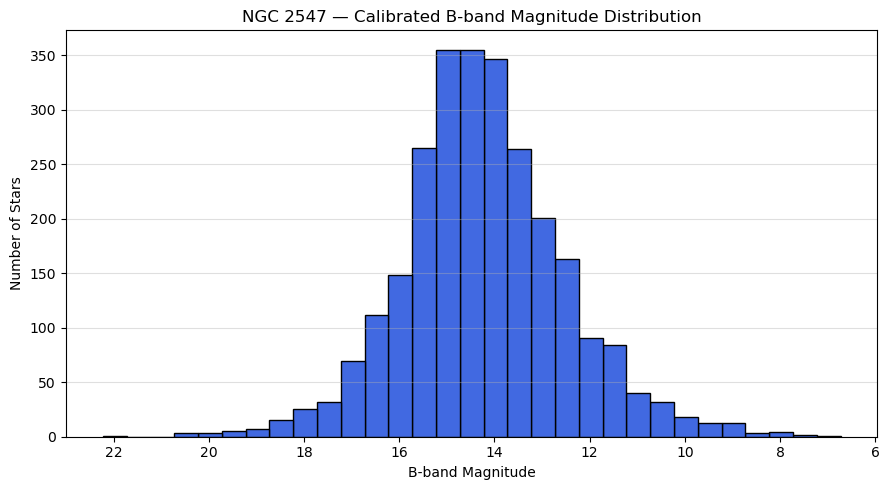

In [8]:

# ── Helper functions ──────────────────────────────────────────────────────────
def net_flux(data, pos, r_ap=20, r_in=25, r_out=40):
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_B(G, G_BP, G_RP):
    
    a0, a1, a2, a3 = 0.00786, 0.92062, -0.25444, 0.05068
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

def BV_from_gaia(G_BP, G_RP):
    
    return 1.35 * (G_BP - G_RP) - 0.10

def V_to_seestar_blue(B, G_BP, G_RP):
    
    BV = BV_from_gaia(G_BP, G_RP)
    return B - 0.63 * BV + 0.01

def seestar_blue_to_B(blue_mag, G_BP, G_RP):
    
    BV = BV_from_gaia(G_BP, G_RP)
    return blue_mag + 0.63 * BV - 0.01

# ── Reference star ────────────────────────────────────────────────────────────

G_BP_ref, G_ref, G_RP_ref = 10.601, 10.386, 10.048
x_ref, y_ref               = 380.3, 459.2

B_ref_johnson  = gaia_to_B(G_ref, G_BP_ref, G_RP_ref)
blue_ref       = V_to_seestar_blue(B_ref_johnson, G_BP_ref, G_RP_ref)
F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("=== Reference Star ===")
print(f"  Johnson B:          {B_ref_johnson:.3f}")
print(f"  SeeStar Blue:       {blue_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# ── Calibrate all sources ─────────────────────────────────────────────────────
maglist   = []   # Calibrated B magnitudes
bluelist  = []   # SeeStar Blue magnitudes (before B correction)

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        blue_mag = blue_ref - 2.5 * np.log10(flux_raw / F_ref)
        bluelist.append(blue_mag)
        # Assume typical cluster colour GBP-GRP ~ 0.7 → B-V ~ 0.85
        blue_to_B_offset = 0.63 * (1.35 * 0.7 - 0.10) - 0.01   # = +0.526
        maglist.append(blue_mag + blue_to_B_offset)
    else:
        bluelist.append(np.nan)
        maglist.append(np.nan)

maglist  = np.array(maglist)
bluelist = np.array(bluelist)

# ── Summary ───────────────────────────────────────────────────────────────────
valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid B magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")

# ── Print first 20 results ────────────────────────────────────────────────────
print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Blue':>8} {'B_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{bluelist[i]:>8.3f} {maglist[i]:>8.3f}")

# ── Histogram ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='royalblue')
plt.xlabel('B-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated B-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("calibrated_B_band_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
import pandas as pd
import numpy as np

df_b = pd.DataFrame({
    "x":       phot_table['xcenter'].value,
    "y":       phot_table['ycenter'].value,
    "raw_flux": phot_table['aperture_sum'],
    "blue_mag": bluelist,
    "B_mag":    maglist
})

df_b = df_b.replace([np.inf, -np.inf], np.nan)
df_b.to_csv("maglist_B_catalog.csv", index=False)
print("CSV saved as maglist_B_catalog.csv")

CSV saved as maglist_B_catalog.csv


# Calibrating and Cataloguing Red band  

In [11]:
r_combined = CCDData.read("r_NGC_2547_med.fits", unit="adu")
print("Loaded r_combined successfully")

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
Loaded r_combined successfully


In [13]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('r_NGC_2547_med.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('r_NGC_2547_med.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

Solving..........WCS added successfully!


In [18]:
scim=CCDData.read("r_NGC_2547_med.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 122.353064205 -48.8903819285 
CRPIX : 587.782646179 483.011875153 
CD1_1 CD1_2  : -0.000595785991798 0.000280943570293 
CD2_1 CD2_2  : -0.000280968045784 -0.000595799946249 
NAXIS : 1080  1920
Image stats (mean, median and standard deviation): -0.16306215524673462 -0.5159013271331787 7.9008941650390625


In [16]:
outfile="segimage_r.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


In [20]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.wcs import WCS
from astropy.io import fits
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.segmentation import SourceCatalog, SegmentationImage
import astropy.stats
import numpy as np

# ── Load R-band image and build source catalogue ──────────────────────────────
with fits.open('r_NGC_2547_med.fits') as hdul:    # ✏️ R-band filename
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage_r.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

# ── Aperture photometry on all detected sources ───────────────────────────────
positions = []
valid_sources = []   # keep track of which sources had valid centroids

for obj in source_table:
    x, y = obj.centroid[0], obj.centroid[1]
    if np.isfinite(x) and np.isfinite(y):   # skip NaN centroids
        positions.append((x, y))
        valid_sources.append(obj)

print(f"Total sources in segmap:       {len(source_table)}")
print(f"Sources with valid centroids:  {len(positions)}")

apertures  = CircularAperture(positions, r=20.0)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

# ── Gaia query ────────────────────────────────────────────────────────────────
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")
j = Gaia.cone_search_async(coordinate=coord, radius=radius)
r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

# ── Match each Gaia star to nearest source in phot_table ─────────────────────
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print("\n=== Candidate REFERENCE stars (G < 12) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

print("\n=== Candidate FAINT stars (15 < G < 18) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

Total sources in segmap:       3112
Sources with valid centroids:  3110

First 10 rows of photometry table:
 id      xcenter            ycenter          aperture_sum   
           pix                pix                           
--- ------------------ ------------------ ------------------
  1 239.46811294795427  2.799366549723335 12681.778686508693
  2  632.1662183036756 1.3602245914813451  40785.23888978646
  3   765.046885903577   1.90396265001212 2214.8024099780296
  4  792.8280346869842 1.8575341697560248  46252.90791551133
  5  933.8680566158353 2.9798255519945527   6821.33308684258
  6  949.0704243711149  1.574036024212375  6677.191642553932
  7  1031.811016409085  9.766994667590062  8891.176393599077
  8  270.9671719291073  5.383191595720728 -969.0948192683088
  9  701.2459087595372  6.394649711992293  8482.615881528547
 10 1069.3657352668936  3.450355437175009 2170.5966391431666

Column names: ['id', 'xcenter', 'ycenter', 'aperture_sum']

Querying Gaia DR3...
INFO: Query finis

In [21]:

a0 = -0.12879
a1 =  0.24662
a2 = -0.027464
a3 = -0.049465

def gaia_to_R(G, G_BP, G_RP):
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

# ── Reference star ────────────────────────────────────────────────────────────
G_BP_ref = 10.601
G_ref    = 10.386
G_RP_ref = 10.048
F_ref    = 82472.3       

# ── Faint star ────────────────────────────────────────────────────────────────
G_BP_faint = 15.433
G_faint    = 15.000
G_RP_faint = 14.406
F_faint    = 1208.4    

R_ref        = gaia_to_R(G_ref,   G_BP_ref,   G_RP_ref)
R_faint_gaia = gaia_to_R(G_faint, G_BP_faint, G_RP_faint)

print("=== Reference Star ===")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated R magnitude: {R_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n=== Faint Star ===")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated R magnitude: {R_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# ── Sanity check ──────────────────────────────────────────────────────────────
R_faint_measured = R_ref - 2.5 * np.log10(F_faint / F_ref)

print("\n=== Sanity Check ===")
print(f"  R (from image photometry): {R_faint_measured:.3f}")
print(f"  R (from Gaia DR3 formula): {R_faint_gaia:.3f}")
print(f"  Difference:                {abs(R_faint_measured - R_faint_gaia):.3f} mag")
if abs(R_faint_measured - R_faint_gaia) < 0.5:
    print("  ✓ Good agreement — calibration is working correctly")
else:
    print("  ✗ Large discrepancy — check aperture photometry or star selection")

=== Reference Star ===
  GBP-GRP colour:         0.553
  Calibrated R magnitude: 10.377
  Measured flux (F_ref):  82472.3 ADU

=== Faint Star ===
  GBP-GRP colour:              1.027
  Gaia-calibrated R magnitude: 15.042
  Measured flux:               1208.4 ADU

=== Sanity Check ===
  R (from image photometry): 14.962
  R (from Gaia DR3 formula): 15.042
  Difference:                0.080 mag
  ✓ Good agreement — calibration is working correctly


=== Reference Star ===
  Cousins R:          10.377
  SeeStar Red:        10.458
  Net flux:           75304.5 ADU
  Background/pixel:   5.699 ADU

=== Calibration Summary ===
  Total sources:         3110
  Valid R magnitudes:    2850
  Magnitude range:       6.24 to 21.93

  idx        x        y     raw_flux      Red    R_mag
-------------------------------------------------------
    0   239.47     2.80      12681.8   12.392   12.293
    1   632.17     1.36      40785.2   11.124   11.025
    2   765.05     1.90       2214.8   14.287   14.188
    3   792.83     1.86      46252.9   10.987   10.888
    4   933.87     2.98       6821.3   13.066   12.966
    5   949.07     1.57       6677.2   13.089   12.989
    6  1031.81     9.77       8891.2   12.778   12.679
    7   270.97     5.38       -969.1      nan      nan
    8   701.25     6.39       8482.6   12.829   12.730
    9  1069.37     3.45       2170.6   14.309   14.209
   10    78.13     9.56       9388.4   12.719   12.619
   11   

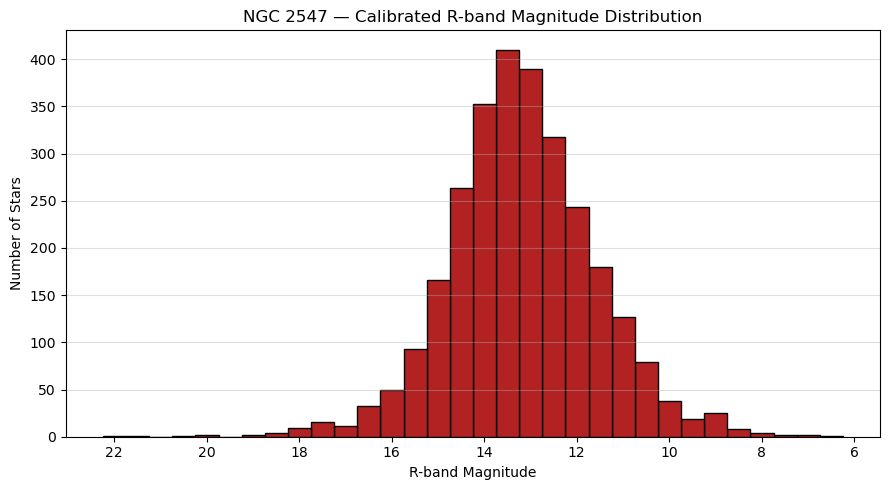

In [22]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

# ── Helper functions ──────────────────────────────────────────────────────────
def net_flux(data, pos, r_ap=20, r_in=25, r_out=40):
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_R(G, G_BP, G_RP):
    """Gaia DR3 → Cousins R using official colour transformation.
    R = G + a0 + a1*(GBP-GRP) + a2*(GBP-GRP)^2 + a3*(GBP-GRP)^3
    Valid for GBP-GRP in range 0.0 to 2.5  (Riello et al. 2021)
    """
    a0, a1, a2, a3 = -0.12879, 0.24662, -0.027464, -0.049465
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

def VR_from_gaia(G_BP, G_RP):
    """Approximate Cousins V-R from Gaia colours."""
    return 0.61 * (G_BP - G_RP) - 0.03

def R_to_seestar_red(R, G_BP, G_RP):
    """Convert Cousins R to expected SeeStar Red magnitude.
    SeeStar Red = R + 0.20*(V-R) + 0.02
    """
    VR = VR_from_gaia(G_BP, G_RP)
    return R + 0.20 * VR + 0.02

def seestar_red_to_R(red_mag, G_BP, G_RP):
    """Convert measured SeeStar Red magnitude back to Cousins R."""
    VR = VR_from_gaia(G_BP, G_RP)
    return red_mag - 0.20 * VR - 0.02

# ── Reference star ────────────────────────────────────────────────────────────
# ✏️ Update these to your chosen reference star from the R-band Gaia table
G_BP_ref, G_ref, G_RP_ref = 10.601, 10.386, 10.048
x_ref, y_ref               = 380.3, 459.2

R_ref_cousins  = gaia_to_R(G_ref, G_BP_ref, G_RP_ref)
red_ref        = R_to_seestar_red(R_ref_cousins, G_BP_ref, G_RP_ref)
F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("=== Reference Star ===")
print(f"  Cousins R:          {R_ref_cousins:.3f}")
print(f"  SeeStar Red:        {red_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# ── Calibrate all sources ─────────────────────────────────────────────────────
maglist  = []   # Calibrated R magnitudes
redlist  = []   # SeeStar Red magnitudes (before R correction)

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        red_mag = red_ref - 2.5 * np.log10(flux_raw / F_ref)
        redlist.append(red_mag)
        # Assume typical cluster colour GBP-GRP ~ 0.7 → V-R ~ 0.40
        red_to_R_offset = -(0.20 * (0.61 * 0.7 - 0.03) + 0.02)   # = -0.093
        maglist.append(red_mag + red_to_R_offset)
    else:
        redlist.append(np.nan)
        maglist.append(np.nan)

maglist = np.array(maglist)
redlist = np.array(redlist)

# ── Summary ───────────────────────────────────────────────────────────────────
valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid R magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")

# ── Print first 20 results ────────────────────────────────────────────────────
print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Red':>8} {'R_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{redlist[i]:>8.3f} {maglist[i]:>8.3f}")

# ── Histogram ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='firebrick')
plt.xlabel('R-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated R-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df_r = pd.DataFrame({
    "x":       phot_table['xcenter'].value,
    "y":       phot_table['ycenter'].value,
    "raw_flux": phot_table['aperture_sum'],
    "red_mag":  redlist,
    "R_mag":    maglist
})

df_r = df_r.replace([np.inf, -np.inf], np.nan)
df_r.to_csv("maglist_R_catalog.csv", index=False)
print("CSV saved as maglist_R_catalog.csv")